In [1]:
from src.gmm import GMM
from src.dg import DataGenerator
from src.metrics import energy_distance, hellinger_gaussian_diag_gmm, hellinger_normal_gmm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t

import torch

## Data generating

In [2]:
# global parameters
N = 2000
d = 3

## Gaussian mixture with $k=5$

In [ ]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()


dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)

In [ ]:
# functions to numerically find the quantile of a 1D Gaussian mixture
def gmm_cdf(x, mu, sigma, pi):
    z = (x - mu) / sigma
    Phi = 0.5 * (1 + torch.erf(z / torch.sqrt(torch.tensor(2., device=z.device))))
    return (pi * Phi).sum()

def gmm_quantile(p, mu, sigma, pi, tol=1e-6, max_iter=100):
    """
    Compute x such that P(X <= x) = p for a 1D Gaussian mixture.
    use binary search (bisection) to numerically find x.
    """
    lo = (mu - 10 * sigma).min()
    hi = (mu + 10 * sigma).max()

    for _ in range(max_iter):
        mid = (lo + hi) / 2
        if gmm_cdf(mid, mu, sigma, pi) < p:
            lo = mid
        else:
            hi = mid

        if (hi - lo) < tol:
            break

    return (lo + hi) / 2

In [5]:
q = gmm_quantile(0.1, mu0[:,0], sigma0[:,0], pi0)
q

tensor(-1.1314)

choice of k = 10


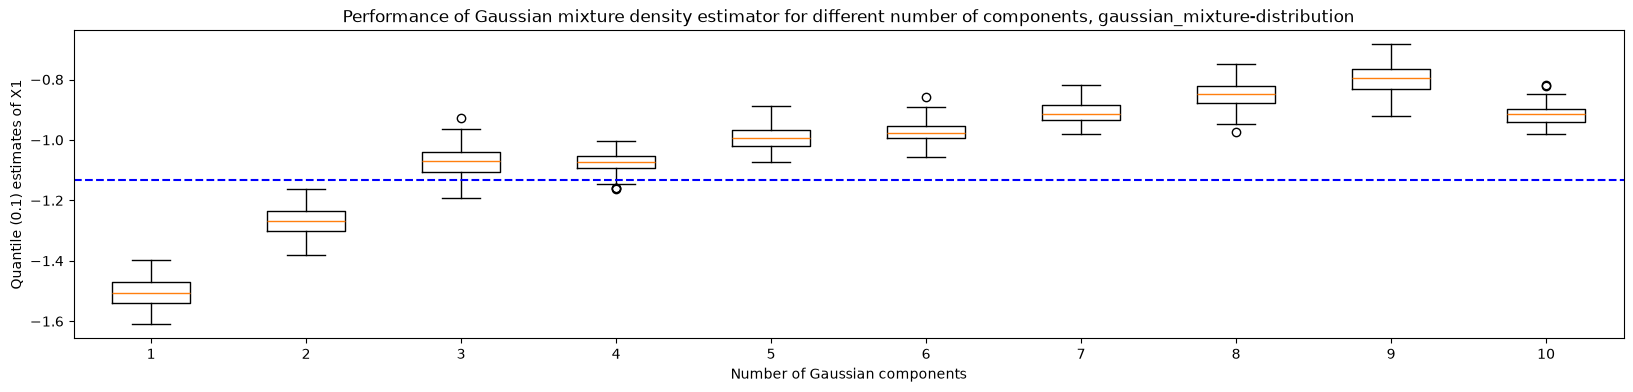

In [6]:
# GMM settings
cov_type = 'id' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 2000

gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q_x1, corr, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples, criterion='aic')

#Plot
positions = np.array(kk)
plt.figure(figsize=(20, 4))
plt.boxplot(q_x1.T, positions=positions)

plt.axhline(y=q, color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates of X1")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

In [ ]:
# generate a new sample from the true Gaussian mixture
# compute the energy distance of it and the sample generated from the estimated Gaussian mixture
X1, _ = dg.generate(N, d)
print('Energy distance of estimated density of X1 and the truth:', energy_distance(X1, gmm.sample_gmm(mu, sigma, pi, N)).item())

Energy distance of estimated density of X1 and the truth: 0.32230669672366474


## Normal with 
$$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

In [8]:
def true_quantile(dist, q=0.1, df=None):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'Logistic':
        return logistic.ppf(q)
    elif dist == 'Student t':
        return t.ppf(q, df)

In [9]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)

choice of k = 8


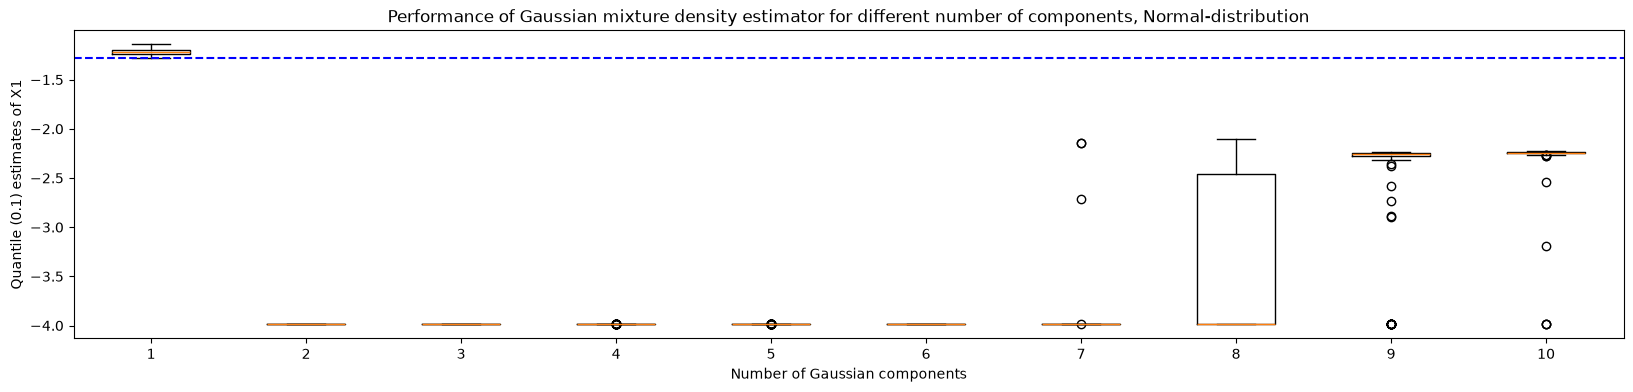

In [10]:
# GMM settings
cov_type = 'id' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 2000

gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q_x1, corr, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples, criterion='bic')

#Plot
positions = np.array(kk)
plt.figure(figsize=(20, 4))
plt.boxplot(q_x1.T, positions=positions)

plt.axhline(y=norm.ppf(0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates of X1")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

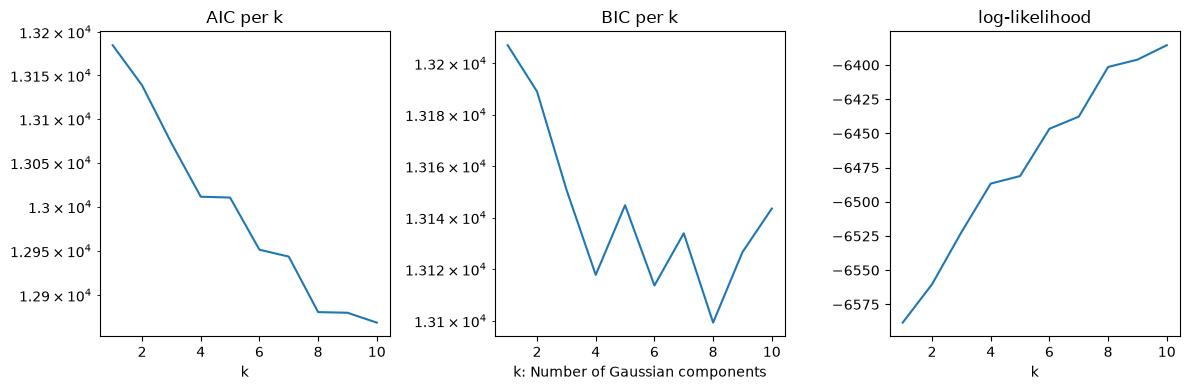

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic)
axs[0].set_yscale('log')
axs[0].set_xlabel('k')
axs[0].set_title('AIC per k')

axs[1].plot(kk, bic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k: Number of Gaussian components')
axs[1].set_title('BIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

In [12]:
ed = energy_distance(X, gmm.sample_gmm(mu, sigma, pi, n_samples))
print(f"Energy distance: {ed.item():.4f}")

Energy distance: 1.0150


In [13]:
print('Hellinger distance of true pdf of X1 (N(0,1)) to the estimated GMM:', hellinger_normal_gmm(0,1,mu[:,0],sigma[:,0],pi).item())

Hellinger distance of true pdf of X1 (N(0,1)) to the estimated GMM: 0.04219326376914978


In [ ]:
# compute Hellinger distance of the true 3D Gaussian and the estimated 3D Gaussian mixture
mu00 = torch.zeros(3)
cov00 = torch.tensor([[1,0.7,0], [0.7,1,0], [0,0,1]])
hellinger_gaussian_diag_gmm(mu00, cov00, mu, sigma, pi).item()

0.3167165517807007